<a href="https://colab.research.google.com/github/epigos/EPIGOS-AI-GAIN-CV-Webinar/blob/main/Epigos_AI_Starter_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Downloads and unzips the tomato leaf diseases dataset from Kaggle.
# https://www.kaggle.com/datasets/farukalam/tomato-leaf-diseases-detection-computer-vision
#!/bin/bash
!kaggle datasets download farukalam/tomato-leaf-diseases-detection-computer-vision --unzip --force -p tomato-leaf

Dataset URL: https://www.kaggle.com/datasets/farukalam/tomato-leaf-diseases-detection-computer-vision
License(s): CC0-1.0
100% 23.9M/23.9M [00:02<00:00, 12.4MB/s]



In [ ]:
# Lists the contents of the downloaded dataset directory.
!ls tomato-leaf/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
# Lists the contents of the 'test' directory within the dataset.
!ls tomato-leaf/test/

images	labels


## Install Epigos AI Python SDK

In [ ]:
# Installs the Epigos AI Python SDK and pybboxes library.
!pip install -q -U epigos pybboxes

In [ ]:
# Installs a specific version of the Pillow library to ensure compatibility.
!pip install --force-reinstall Pillow==10.4.0

  Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
Using cached pillow-10.4.0-cp312-cp312-manylinux_2_28_x86_64.whl (4.5 MB)
  Attempting uninstall: Pillow
    Found existing installation: pillow 10.4.0
    Uninstalling pillow-10.4.0:
      Successfully uninstalled pillow-10.4.0


## Import packages

In [ ]:
# Imports necessary libraries for file path manipulation, image processing, numerical operations, plotting, and Epigos AI SDK functionalities.
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

import epigos
from epigos.dataset import utils as dataset_utils

## Read the data directory

In [ ]:
# Defines paths to the dataset's images, annotations, and data configuration file.
dataset_path = Path("./tomato-leaf/")

images_directory_path = dataset_path / "test" / 'images'
annotations_directory_path = dataset_path / "test" / 'labels'
data_yaml_path = dataset_path / 'data.yaml'

In [ ]:
# Reads the YOLO-formatted dataset, extracting class labels, image paths, and annotations.
classes, imgs, annotations = dataset_utils.read_yolo_directory(
    images_directory_path=images_directory_path,
    annotations_directory_path=annotations_directory_path,
    data_yaml_path=data_yaml_path
)

In [ ]:
# Prints the extracted class labels from the dataset.
print("Class labels: ", classes)

Class labels:  ['Bacterial Spot', 'Early_Blight', 'Healthy', 'Late_blight', 'Leaf Mold', 'Target_Spot', 'black spot']


In [ ]:
# Prints the total number of test images loaded.
print("Number of test images", len(imgs))

Number of test images 31


In [ ]:
# Selects a sample image key and displays its associated annotations.
sample_img_key = list(imgs.keys())[2]
annotations[sample_img_key]

[Detection(bbox=(222, 60, 18, 13), class_name='Early_Blight', class_id=1),
 Detection(bbox=(276, 74, 9, 8), class_name='Early_Blight', class_id=1),
 Detection(bbox=(238, 185, 30, 16), class_name='Early_Blight', class_id=1),
 Detection(bbox=(481, 189, 15, 9), class_name='Early_Blight', class_id=1),
 Detection(bbox=(323, 104, 17, 12), class_name='Early_Blight', class_id=1),
 Detection(bbox=(270, 94, 12, 6), class_name='Early_Blight', class_id=1),
 Detection(bbox=(262, 250, 18, 11), class_name='Early_Blight', class_id=1),
 Detection(bbox=(237, 248, 15, 10), class_name='Early_Blight', class_id=1),
 Detection(bbox=(193, 246, 24, 12), class_name='Early_Blight', class_id=1),
 Detection(bbox=(468, 238, 18, 11), class_name='Early_Blight', class_id=1),
 Detection(bbox=(340, 182, 14, 10), class_name='Early_Blight', class_id=1),
 Detection(bbox=(384, 416, 20, 12), class_name='Early_Blight', class_id=1),
 Detection(bbox=(257, 539, 20, 14), class_name='Early_Blight', class_id=1),
 Detection(bbox=(21

## Visualize a sample image

In [ ]:
def draw_annotations(image_path, annotations):
    """
    Draws bounding box annotations on an image using Matplotlib.

    Args:
        image_path (pathlib.Path or str): Path to the image file.
        annotations (list): A list of annotation objects. In this notebook's context,
                            these are epigos.dataset.Detection objects, each having
                            a 'bbox' attribute (x, y, width, height) and 'class_name'.
    """
    # Load the image
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return

    # Convert BGR image (from OpenCV) to RGB (for Matplotlib)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create a Matplotlib figure and axes
    fig, ax = plt.subplots(1, figsize=(10, 10))
    ax.imshow(image)

    # Iterate through annotations and draw bounding boxes and labels
    for ann in annotations:
        # Extract bbox in (x, y, width, height) format
        x, y, w, h = ann.bbox

        # Create a rectangle patch
        rect = plt.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Add class name as text label
        if ann.class_name:
            plt.text(x, y - 5, ann.class_name, color='white', fontsize=10,
                     bbox=dict(facecolor='red', alpha=0.7, edgecolor='none', pad=1))

    # Hide axes ticks and labels for a cleaner view
    ax.axis('off')
    plt.show()

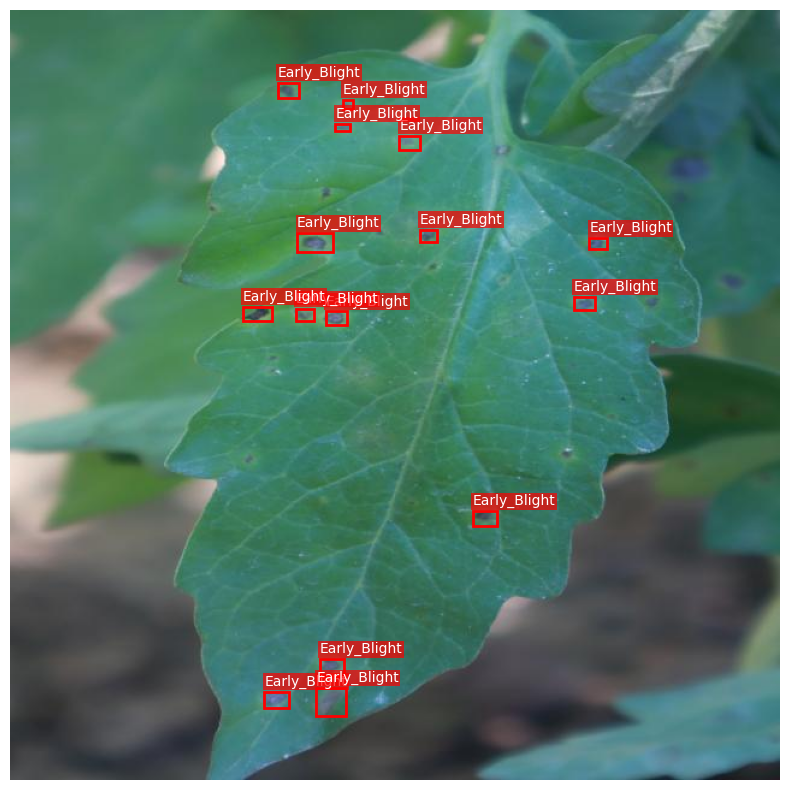

In [ ]:
# Prepares the image path for visualization and calls the draw_annotations function.
image_path = imgs[sample_img_key]

draw_annotations(
    image_path, annotations[sample_img_key]
)

## Initialize Project and Upload dataset

In [ ]:
# Authenticates with Epigos AI using an API key and initializes the Epigos client and project.
from google.colab import userdata

EPIGOS_AI_API_KEY = userdata.get('EPIGOS_AI_API_KEY')
EPIGOS_AI_PROJECT_ID = "70ce57c4-1fc5-41ff-89ca-32f52e13525c"

client = epigos.Epigos(EPIGOS_AI_API_KEY, timeout=45.0)
project = client.project(EPIGOS_AI_PROJECT_ID)

In [ ]:
# Uploads the YOLO-formatted dataset to the Epigos AI project.
records = project.upload_yolo_dataset(
    images_directory=images_directory_path,
    annotations_directory=annotations_directory_path,
    data_yaml_path=data_yaml_path,
    batch_name="GAIN-2"
)
_ = list(records)


Uploading datasets: 100%|██████████| 31/31 [00:22<00:00,  1.38it/s]


## Inference via the SDK

In [ ]:
# Loads a pre-trained object detection model from Epigos AI using its model ID.
MODEL_ID = "43846b68-b11d-4a60-abca-68f3e0bee8fd"

od_model = client.object_detection(MODEL_ID)


In [ ]:
# Performs object detection on the sample image using the loaded model and displays the results.
results = od_model.detect(str(image_path), confidence=0.5)
results.dict()

{'detections': [{'label': 'Early_Blight',
   'confidence': 0.7289,
   'x': 254,
   'y': 563,
   'width': 26,
   'height': 21},
  {'label': 'Early_Blight',
   'confidence': 0.6982,
   'x': 204,
   'y': 567,
   'width': 26,
   'height': 13},
  {'label': 'Early_Blight',
   'confidence': 0.6828,
   'x': 237,
   'y': 187,
   'width': 29,
   'height': 16},
  {'label': 'Early_Blight',
   'confidence': 0.6011,
   'x': 196,
   'y': 247,
   'width': 22,
   'height': 12},
  {'label': 'Early_Blight',
   'confidence': 0.5438,
   'x': 467,
   'y': 240,
   'width': 18,
   'height': 12},
  {'label': 'Early_Blight',
   'confidence': 0.5371,
   'x': 217,
   'y': 63,
   'width': 19,
   'height': 14},
  {'label': 'Early_Blight',
   'confidence': 0.531,
   'x': 384,
   'y': 420,
   'width': 20,
   'height': 11}],
 'base64_image': '...'}

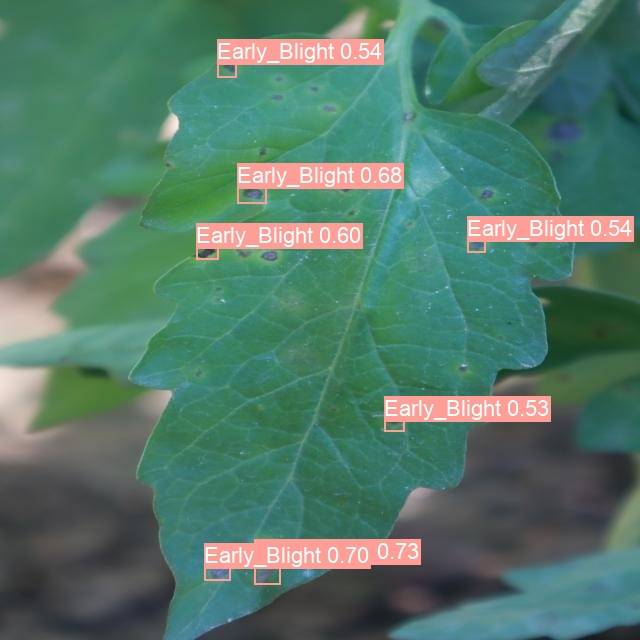

In [ ]:
# Visualizes the detected objects on the image.
results.get_image()